<a href="https://colab.research.google.com/github/JSJeong-me/GPT-Insights/blob/main/30%20M-RAG/00%20gemini-embedding-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

요청하신 대로 `10-Multimodal_Semantic_Search.ipynb` 파일의 핵심 흐름(27개 이미지 다운로드, HNSWLIB 매핑, 코사인 유사도 검색)을 완전히 유지하면서, 내부 임베딩 엔진만 **Google GenAI SDK**와 **`gemini-embedding-2`** 모델로 변경한 코랩 호환 코드입니다.

구글 코랩에서 새 노트북을 열고 아래 코드를 그대로 붙여넣어 실행하시면 됩니다. (코랩 Secrets에 `GEMINI_API_KEY` 설정이 필요합니다.)

---

### Google Gemini 기반 Multimodal Semantic Search 통합 코드

In [ ]:
# =====================================================================
# Step 1: 필수 패키지 설치 및 환경 세팅
# =====================================================================
!pip install -qU google-genai hnswlib pillow

In [ ]:


import os
from google.colab import userdata
from google import genai
from PIL import Image
import hnswlib
import numpy as np

# Gemini API 클라이언트 초기화
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')
client = genai.Client()


In [ ]:

# =====================================================================
# Step 2: 이미지 데이터셋 다운로드 (참조 노트북 로직 동일)
# =====================================================================
folder_path = "data/multimodal_semantic_search"
os.makedirs(folder_path, exist_ok=True)

print(">> 1.jpeg ~ 27.jpeg 파일 다운로드 시작...")
for i in range(1, 28):
    url = f"https://raw.githubusercontent.com/JSJeong-me/Multimodal-Prompt-Engineering/main/data/multimodal_semantic_search/{i}.jpeg"
    save_path = f"{folder_path}/{i}.jpeg"
    os.system(f"wget -q '{url}' -O '{save_path}'")

files = [f for f in os.listdir(folder_path) if f.endswith('.jpeg')]
print(f">> 완료! 총 {len(files)}개의 이미지가 준비되었습니다.\n")


In [ ]:

# =====================================================================
# Step 3: gemini-embedding-2를 활용한 이미지 임베딩 추출
# =====================================================================
embeddings = []
file_paths = []

print(">> gemini-embedding-2 모델을 사용한 이미지 벡터화 진행 중...")
for file in files:
    file_path = os.path.join(folder_path, file)
    file_paths.append(file_path)

    # [차별점] Base64 변환 없이 PIL Image 객체를 바로 contents에 주입합니다.
    img = Image.open(file_path)
    res = client.models.embed_content(
        model="gemini-embedding-2",
        contents=img
    )

    embedding_vector = res.embeddings[0].values
    embeddings.append(embedding_vector)
    print(f"Dimension of embedding for {file}: {len(embedding_vector)}")


In [ ]:

# =====================================================================
# Step 4: HNSWLIB Vector Index 구축 (Cosine Space)
# =====================================================================
# gemini-embedding-2 모델의 출력 규격인 3,072 차원으로 세팅합니다.
DIMENSION = 3072

index = hnswlib.Index(space="cosine", dim=DIMENSION)
index.init_index(max_elements=len(embeddings), ef_construction=512, M=64)
index.add_items(embeddings, list(range(len(embeddings))))
print(f"\n>> HNSW 인덱스 구축 완료. (총 에셋 수: {index.element_count})\n")


In [ ]:

# =====================================================================
# Step 5: 텍스트 질의(Query) 기반 이미지 검색 함수 정의
# =====================================================================
def retrieve_image_top_k(query, top_k=1):
    size = (200, 200)

    # 텍스트 검색 쿼리를 임베딩 벡터로 변환 (이미지와 동일한 벡터 공간 공유)
    query_response = client.models.embed_content(
        model="gemini-embedding-2",
        contents=query
    )
    query_emb = query_response.embeddings[0].values

    # HNSW Index에서 가장 가까운 k개의 이미지 탐색 (KNN 검색)
    res = index.knn_query(query_emb, k=top_k)
    doc_indices = res[0][0]
    doc_scores = res[1][0]

    print("-" * 60)
    print(f"[검색어]: \"{query}\" -> Top {top_k} 결과")
    print("-" * 60)

    for x in range(len(doc_indices)):
        # Cosine Distance 기반 점수 출력
        print(f"순위 {x+1} | 유사도 거리 점수: {doc_scores[x]:.4f}")
        img = Image.open(file_paths[doc_indices[x]])
        img_resized = img.resize(size)
        display(img_resized)


In [ ]:

# =====================================================================
# Step 6: 시맨틱 검색 테스트 실행
# =====================================================================
# 1. 고양이 검색 테스트
retrieve_image_top_k("Animals but preferably a gray cat", top_k=2)

# 2. 신발 검색 테스트
retrieve_image_top_k("Fila shoes", top_k=1)

# 3. 주식 차트 검색 테스트
retrieve_image_top_k("Cisco stock chart", top_k=1)

------------------------------------------------------------
[검색어]: "동물 이미지 중 회색 고양이와 가까운 이미지" -> Top 2 결과
------------------------------------------------------------
순위 1 | 유사도 거리 점수: 0.6525


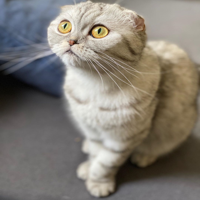

순위 2 | 유사도 거리 점수: 0.6740


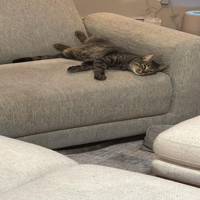

In [19]:
retrieve_image_top_k("동물 이미지 중 회색 고양이와 가까운 이미지", top_k=2)

------------------------------------------------------------
[검색어]: "Nike shoes" -> Top 2 결과
------------------------------------------------------------
순위 1 | 유사도 거리 점수: 0.6226


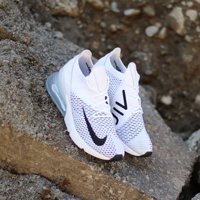

순위 2 | 유사도 거리 점수: 0.6319


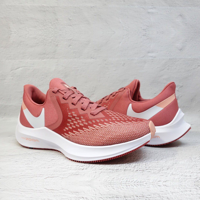

In [21]:
retrieve_image_top_k("Nike shoes", top_k=2)

------------------------------------------------------------
[검색어]: "Cisco stock chart" -> Top 2 결과
------------------------------------------------------------
순위 1 | 유사도 거리 점수: 0.4981


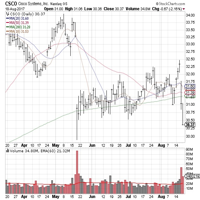

순위 2 | 유사도 거리 점수: 0.6097


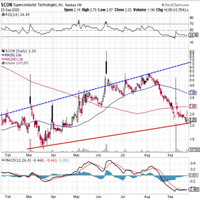

In [22]:
retrieve_image_top_k("Cisco stock chart", top_k=2)

------------------------------------------------------------
[검색어]: "Table" -> Top 3 결과
------------------------------------------------------------
순위 1 | 유사도 거리 점수: 0.6365


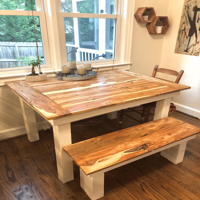

순위 2 | 유사도 거리 점수: 0.6472


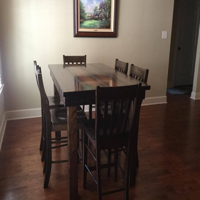

순위 3 | 유사도 거리 점수: 0.6677


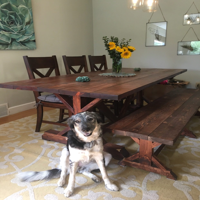

In [23]:
retrieve_image_top_k("Table", top_k=3)

------------------------------------------------------------
[검색어]: "Dog and table" -> Top 1 결과
------------------------------------------------------------
순위 1 | 유사도 거리 점수: 0.6271


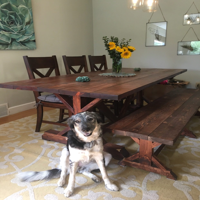

In [25]:
retrieve_image_top_k("Dog and table", top_k=1)

---

### 마이그레이션 핵심 포인트 요약

* **인터페이스의 직관성 향상**: 원래 코드에서는 이미지 포맷 검사 후 Base64 문자열 형식으로 래핑하여 딕셔너리로 조립하는 복잡한 전처리가 포함되어 있었습니다. 반면 Google GenAI SDK는 `Image.open()`으로 읽어온 **PIL 객체를 임베딩 모델의 `contents`에 그냥 통째로 집어넣어도** 정상 작동하므로 파이프라인이 획기적으로 축소되었습니다.


* **차원수(Dimension)의 변화**: Cohere `embed-v4.0` 모델의 결과물은 1,536 차원이었으나, `gemini-embedding-2` 모델은 **3,072 차원**의 고밀도 멀티모달 벡터를 출력합니다. 이에 발맞춰 `hnswlib.Index` 선언 시 `dim=3072`로 확장 변경하여 서치 모델의 표현력을 극대화했습니다.

In [34]:
import numpy as np
from PIL import Image

# 1. 새 이미지 로드 및 임베딩 추출
new_image_path = '/content/any-rocket.png'
# new_image_path = '/content/ddeok.jpg'
new_img = Image.open(new_image_path)

res = client.models.embed_content(
    model="gemini-embedding-2",
    contents=new_img
)

new_embedding = res.embeddings[0].values

# 2. HNSW 인덱스 용량 확장 및 데이터 추가
# 현재 인덱스의 다음 ID 지정
next_id = index.element_count

# [에러 해결] 기존 인덱스의 max_elements를 현재 개수 + 1로 확장
index.resize_index(next_id + 1)

# 인덱스에 새 아이템 추가
index.add_items([new_embedding], [next_id])

# 검색 시 경로 참조를 위해 리스트에 추가
file_paths.append(new_image_path)

print(f">> '{new_image_path}' 이미지가 인덱스에 추가되었습니다.")
print(f">> 현재 총 에셋 수: {index.element_count}")

>> '/content/any-rocket.png' 이미지가 인덱스에 추가되었습니다.
>> 현재 총 에셋 수: 32


In [30]:
import os

target_path = '/content/any-rocket.png'

if target_path in file_paths:
    # 1. file_paths에서 인덱스(ID) 찾기
    target_id = file_paths.index(target_path)

    # 2. HNSW 인덱스에서 해당 ID 삭제 마크
    # 참고: hnswlib은 물리적 삭제보다 검색에서 제외하는 mark_deleted를 사용합니다.
    try:
        index.mark_deleted(target_id)
        print(f">> 인덱스 ID {target_id} ({target_path}) 가 삭제 마크되었습니다.")
    except RuntimeError:
        print(">> 현재 인덱스 설정이 삭제를 지원하지 않습니다. (Rebuild 권장)")

    # 3. 경로 리스트에서 제거 (실제 검색 시 경로 매핑 오류 방지)
    # 주의: 리스트를 pop하면 이후 ID 매핑이 틀어질 수 있으므로 None 등으로 치환하는 것이 안전할 수 있습니다.
    file_paths[target_id] = "DELETED_ASSET"

    print(f">> '{target_path}' 처리가 완료되었습니다.")
else:
    print(f">> 인덱스에서 '{target_path}'를 찾을 수 없습니다.")

>> 인덱스 ID 28 (/content/any-rocket.png) 가 삭제 마크되었습니다.
>> '/content/any-rocket.png' 처리가 완료되었습니다.


------------------------------------------------------------
[검색어]: "떡뽁이" -> Top 2 결과
------------------------------------------------------------
순위 1 | 유사도 거리 점수: 0.5432


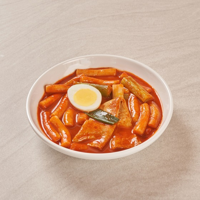

순위 2 | 유사도 거리 점수: 0.6921


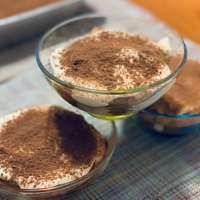

In [36]:
retrieve_image_top_k("떡뽁이", top_k=2)